<a href="https://www.kaggle.com/code/aamir28/hiit-vs-hypertrophy-analysis?scriptVersionId=322171592" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

# HIIT vs Hypertrophy: A 12-Week Body Composition Battle

<div style="background:linear-gradient(135deg,#0f0f1a 0%,#1a1a2e 50%,#16213e 100%);border-radius:16px;padding:36px 40px;font-family:'Segoe UI',sans-serif;color:#e0e0e0;border:1px solid #2a2a4a;">
  <div style="display:flex;align-items:center;gap:16px;margin-bottom:24px;">
    <div style="font-size:48px;">💪</div>
    <div>
      <h1 style="margin:0;font-size:2rem;font-weight:800;background:linear-gradient(90deg,#e94560,#f5a623);-webkit-background-clip:text;-webkit-text-fill-color:transparent;">HIIT vs Hypertrophy Gains</h1>
      <p style="margin:4px 0 0;color:#888;font-size:0.95rem;">12-Week Randomized Controlled Study · 200 Participants · Body Composition Analysis</p>
    </div>
  </div>
  <hr style="border:none;border-top:1px solid #2a2a4a;margin:20px 0;">
  <div style="display:grid;grid-template-columns:repeat(4,1fr);gap:20px;margin-bottom:28px;">
    <div style="background:#1e1e30;border-radius:12px;padding:18px;text-align:center;border:1px solid #2a2a4a;">
      <div style="font-size:2rem;font-weight:800;color:#e94560;">200</div>
      <div style="font-size:0.8rem;color:#888;margin-top:4px;">Participants</div>
    </div>
    <div style="background:#1e1e30;border-radius:12px;padding:18px;text-align:center;border:1px solid #2a2a4a;">
      <div style="font-size:2rem;font-weight:800;color:#f5a623;">3</div>
      <div style="font-size:0.8rem;color:#888;margin-top:4px;">Training Groups</div>
    </div>
    <div style="background:#1e1e30;border-radius:12px;padding:18px;text-align:center;border:1px solid #2a2a4a;">
      <div style="font-size:2rem;font-weight:800;color:#00d4aa;">12</div>
      <div style="font-size:0.8rem;color:#888;margin-top:4px;">Weeks Duration</div>
    </div>
    <div style="background:#1e1e30;border-radius:12px;padding:18px;text-align:center;border:1px solid #2a2a4a;">
      <div style="font-size:2rem;font-weight:800;color:#a78bfa;">12</div>
      <div style="font-size:0.8rem;color:#888;margin-top:4px;">Features Tracked</div>
    </div>
  </div>
  <div style="background:#1e1e30;border-radius:12px;padding:20px 24px;border-left:4px solid #e94560;">
    <h3 style="margin:0 0 10px;color:#e94560;font-size:1rem;">🔬 Study Overview</h3>
    <p style="margin:0;line-height:1.7;color:#ccc;font-size:0.92rem;">
      This dataset captures a 12-week randomized controlled trial comparing three training protocols:
      <strong style="color:#e94560;">HIIT Only</strong>, <strong style="color:#f5a623;">Hypertrophy Only</strong>, and
      <strong style="color:#00d4aa;">Concurrent Training</strong>. Participants were tracked across body fat %,
      lean mass, VO₂ Max, compliance rates, and dietary conditions. The goal: determine which protocol
      delivers superior body recomposition outcomes across diverse demographics.
    </p>
  </div>
  <div style="margin-top:20px;display:flex;gap:12px;flex-wrap:wrap;">
    <span style="background:#1e1e30;border:1px solid #e94560;color:#e94560;padding:6px 14px;border-radius:20px;font-size:0.8rem;">🏃 HIIT · n=61</span>
    <span style="background:#1e1e30;border:1px solid #f5a623;color:#f5a623;padding:6px 14px;border-radius:20px;font-size:0.8rem;">🏋️ Hypertrophy · n=76</span>
    <span style="background:#1e1e30;border:1px solid #00d4aa;color:#00d4aa;padding:6px 14px;border-radius:20px;font-size:0.8rem;">⚡ Concurrent · n=63</span>
    <span style="background:#1e1e30;border:1px solid #a78bfa;color:#a78bfa;padding:6px 14px;border-radius:20px;font-size:0.8rem;">👤 106 Male · 94 Female</span>
    <span style="background:#1e1e30;border:1px solid #60a5fa;color:#60a5fa;padding:6px 14px;border-radius:20px;font-size:0.8rem;">🍽️ Surplus · Deficit · Maintenance</span>
  </div>
  <div style="margin-top:20px;font-size:0.78rem;color:#555;text-align:right;">Author: Muhammad Aamir &nbsp;|&nbsp; Kaggle Notebook</div>
</div>


## 📋 Table of Contents

1. [Setup & Data Loading](#1-setup)
2. [Dataset Overview & EDA](#2-eda)
3. [Feature Engineering](#3-features)
4. [Group Comparison: Fat Loss, Lean Gain, VO₂ Max](#4-comparison)
5. [Gender & Age Analysis](#5-demographics)
6. [Diet × Training Interaction](#6-diet)
7. [Compliance Analysis](#7-compliance)
8. [Correlation Heatmap](#8-correlation)
9. [Scatter & Distribution Deep-Dives](#9-scatter)
10. [Key Takeaways](#10-takeaways)


## 1. Setup & Data Loading <a id='1-setup'></a>


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
from matplotlib.colors import LinearSegmentedColormap
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# ── Global Style ──────────────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.facecolor': '#0f0f1a',
    'axes.facecolor':   '#1a1a2e',
    'axes.edgecolor':   '#2a2a4a',
    'axes.labelcolor':  '#cccccc',
    'axes.titlecolor':  '#ffffff',
    'axes.titlesize':   13,
    'axes.labelsize':   11,
    'xtick.color':      '#888888',
    'ytick.color':      '#888888',
    'text.color':       '#cccccc',
    'grid.color':       '#2a2a4a',
    'grid.linewidth':   0.7,
    'legend.facecolor': '#1e1e30',
    'legend.edgecolor': '#2a2a4a',
    'font.family':      'DejaVu Sans',
})

PALETTE = {
    'HIIT_Only':        '#e94560',
    'Hypertrophy_Only': '#f5a623',
    'Concurrent':       '#00d4aa',
}
GROUP_LABELS = {
    'HIIT_Only':        'HIIT Only',
    'Hypertrophy_Only': 'Hypertrophy',
    'Concurrent':       'Concurrent',
}

print('Libraries loaded. Style configured. Ready to analyse.')


Libraries loaded. Style configured. Ready to analyse.


In [2]:
df = pd.read_csv('/kaggle/input/datasets/sohaibdevv/hiit-vs-hypertrophy-gains-dataset/hiit_vs_hypertrophy_gains.csv')
print(f'Shape: {df.shape}')
df.head(10)

Shape: (200, 12)


,Participant_ID,Age,Gender,Group,Duration_Weeks,Compliance_Rate,Initial_Body_Fat_Pct,Final_Body_Fat_Pct,Initial_Lean_Mass_kg,Final_Lean_Mass_kg,VO2_Max_Change_Pct,Dietary_Condition
0,P001,46,Female,Hypertrophy_Only,12,0.71,26.7,25.5,47.0,49.1,3.1,Surplus
1,P002,32,Female,Hypertrophy_Only,12,0.89,31.6,29.5,47.1,51.5,2.7,Surplus
2,P003,25,Male,HIIT_Only,12,0.88,13.7,10.6,72.0,71.8,11.3,Deficit
3,P004,38,Female,Concurrent,12,0.96,30.9,28.0,44.0,47.2,12.5,Surplus
4,P005,36,Female,HIIT_Only,12,0.66,23.9,23.2,55.6,55.3,11.9,Surplus
5,P006,40,Male,Hypertrophy_Only,12,0.90,17.1,14.7,69.7,70.4,0.2,Deficit
6,P007,28,Male,Concurrent,12,0.93,18.8,15.9,78.9,80.8,8.8,Surplus
7,P008,28,Female,Hypertrophy_Only,12,0.96,22.4,19.4,43.2,44.1,0.1,Deficit
8,P009,41,Male,Hypertrophy_Only,12,0.79,21.7,19.5,75.5,76.1,0.3,Deficit
9,P010,53,Male,Hypertrophy_Only,12,0.77,15.1,12.9,64.3,65.7,2.6,Deficit


## 2. Dataset Overview & EDA <a id='2-eda'></a>


In [3]:
print('=== Data Types & Nulls ===')
print(df.info())
print('\n=== Descriptive Statistics ===')
df.describe().round(2)


=== Data Types & Nulls ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Participant_ID        200 non-null    object 
 1   Age                   200 non-null    int64  
 2   Gender                200 non-null    object 
 3   Group                 200 non-null    object 
 4   Duration_Weeks        200 non-null    int64  
 5   Compliance_Rate       200 non-null    float64
 6   Initial_Body_Fat_Pct  200 non-null    float64
 7   Final_Body_Fat_Pct    200 non-null    float64
 8   Initial_Lean_Mass_kg  200 non-null    float64
 9   Final_Lean_Mass_kg    200 non-null    float64
 10  VO2_Max_Change_Pct    200 non-null    float64
 11  Dietary_Condition     200 non-null    object 
dtypes: float64(6), int64(2), object(4)
memory usage: 18.9+ KB
None

=== Descriptive Statistics ===


,Age,Duration_Weeks,Compliance_Rate,Initial_Body_Fat_Pct,Final_Body_Fat_Pct,Initial_Lean_Mass_kg,Final_Lean_Mass_kg,VO2_Max_Change_Pct
count,200.00,200.0,200.00,200.00,200.00,200.00,200.00,200.00
mean,35.88,12.0,0.84,23.00,20.93,61.64,62.85,7.48
std,11.15,0.0,0.11,5.89,5.95,13.19,13.21,5.60
min,18.00,12.0,0.42,12.10,8.90,42.20,42.00,-0.90
25%,25.75,12.0,0.77,18.50,16.50,49.58,51.32,2.70
50%,36.50,12.0,0.85,22.50,20.50,61.30,62.10,6.80
75%,45.00,12.0,0.93,27.70,25.50,73.53,74.77,11.40
max,54.00,12.0,1.00,33.90,32.70,85.00,87.40,21.30


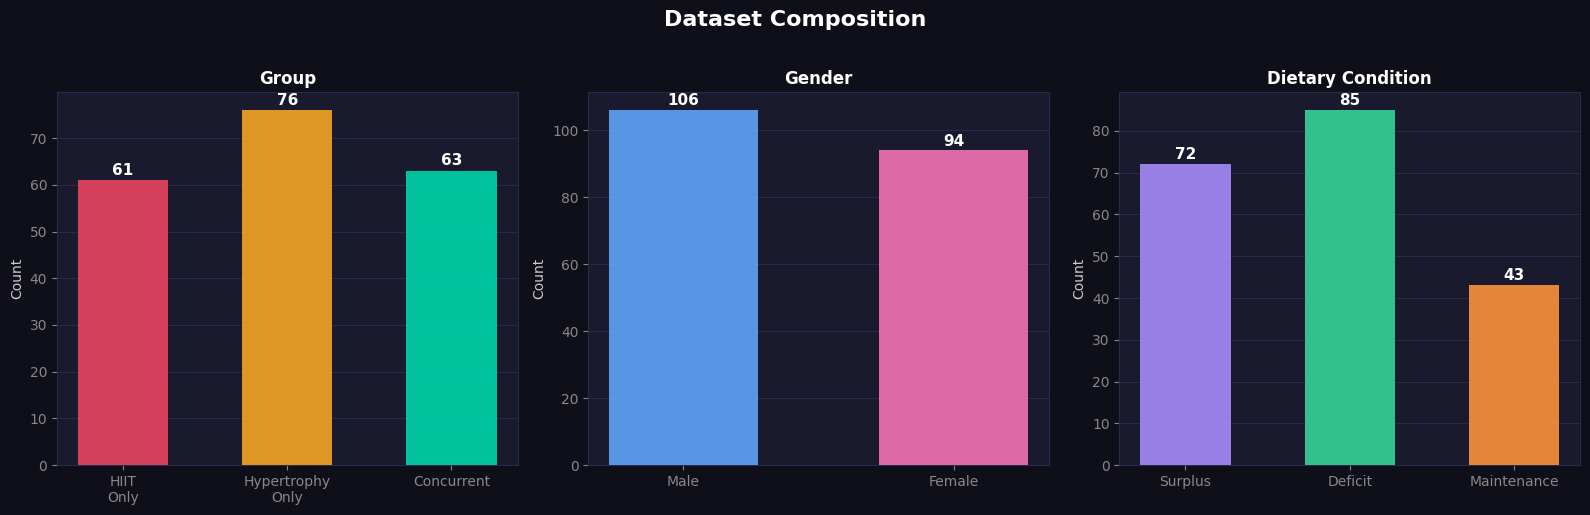

In [4]:
# Distribution of categorical variables
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Dataset Composition', fontsize=16, fontweight='bold', color='white', y=1.02)

cats = [
    ('Group',              ['HIIT_Only', 'Hypertrophy_Only', 'Concurrent'],
     ['#e94560', '#f5a623', '#00d4aa']),
    ('Gender',             ['Male', 'Female'],
     ['#60a5fa', '#f472b6']),
    ('Dietary_Condition',  ['Surplus', 'Deficit', 'Maintenance'],
     ['#a78bfa', '#34d399', '#fb923c']),
]

for ax, (col, order, colors) in zip(axes, cats):
    counts = df[col].value_counts().reindex(order)
    bars = ax.bar(range(len(order)), counts.values, color=colors,
                  width=0.55, zorder=3, edgecolor='none', alpha=0.9)
    ax.set_xticks(range(len(order)))
    ax.set_xticklabels([o.replace('_', '\n') for o in order], fontsize=10)
    ax.set_ylabel('Count', fontsize=10)
    ax.set_title(col.replace('_', ' '), fontsize=12, fontweight='bold')
    ax.grid(axis='y', zorder=0)
    ax.set_axisbelow(True)
    for bar, v in zip(bars, counts.values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                str(v), ha='center', va='bottom', fontsize=11,
                fontweight='bold', color='white')

plt.tight_layout()
plt.savefig('01_dataset_composition.png', dpi=150, bbox_inches='tight',
            facecolor='#0f0f1a')
plt.show()


## 3. Feature Engineering <a id='3-features'></a>


In [5]:
# Derived metrics
df['Fat_Loss_Pct']       = df['Initial_Body_Fat_Pct'] - df['Final_Body_Fat_Pct']
df['Lean_Mass_Gain_kg']  = df['Final_Lean_Mass_kg']   - df['Initial_Lean_Mass_kg']
df['Body_Recomp_Score']  = df['Fat_Loss_Pct'] + df['Lean_Mass_Gain_kg']  # composite
df['Age_Group']          = pd.cut(df['Age'], bins=[17,25,35,45,55],
                                  labels=['18–25','26–35','36–45','46–55'])

print('New columns added:')
print(df[['Fat_Loss_Pct','Lean_Mass_Gain_kg','Body_Recomp_Score','Age_Group']].describe().round(3))
df.head(5)


New columns added:
       Fat_Loss_Pct  Lean_Mass_Gain_kg  Body_Recomp_Score
count       200.000            200.000            200.000
mean          2.067              1.204              3.271
std           0.797              1.146              1.333
min           0.400             -0.400              0.400
25%           1.400              0.400              2.200
50%           2.000              0.900              3.200
75%           2.700              1.700              4.100
max           3.900              4.800              6.900


,Participant_ID,Age,Gender,Group,Duration_Weeks,Compliance_Rate,Initial_Body_Fat_Pct,Final_Body_Fat_Pct,Initial_Lean_Mass_kg,Final_Lean_Mass_kg,VO2_Max_Change_Pct,Dietary_Condition,Fat_Loss_Pct,Lean_Mass_Gain_kg,Body_Recomp_Score,Age_Group
0,P001,46,Female,Hypertrophy_Only,12,0.71,26.7,25.5,47.0,49.1,3.1,Surplus,1.2,2.1,3.3,46–55
1,P002,32,Female,Hypertrophy_Only,12,0.89,31.6,29.5,47.1,51.5,2.7,Surplus,2.1,4.4,6.5,26–35
2,P003,25,Male,HIIT_Only,12,0.88,13.7,10.6,72.0,71.8,11.3,Deficit,3.1,-0.2,2.9,18–25
3,P004,38,Female,Concurrent,12,0.96,30.9,28.0,44.0,47.2,12.5,Surplus,2.9,3.2,6.1,36–45
4,P005,36,Female,HIIT_Only,12,0.66,23.9,23.2,55.6,55.3,11.9,Surplus,0.7,-0.3,0.4,36–45


## 4. Group Comparison: Fat Loss, Lean Gain & VO₂ Max <a id='4-comparison'></a>


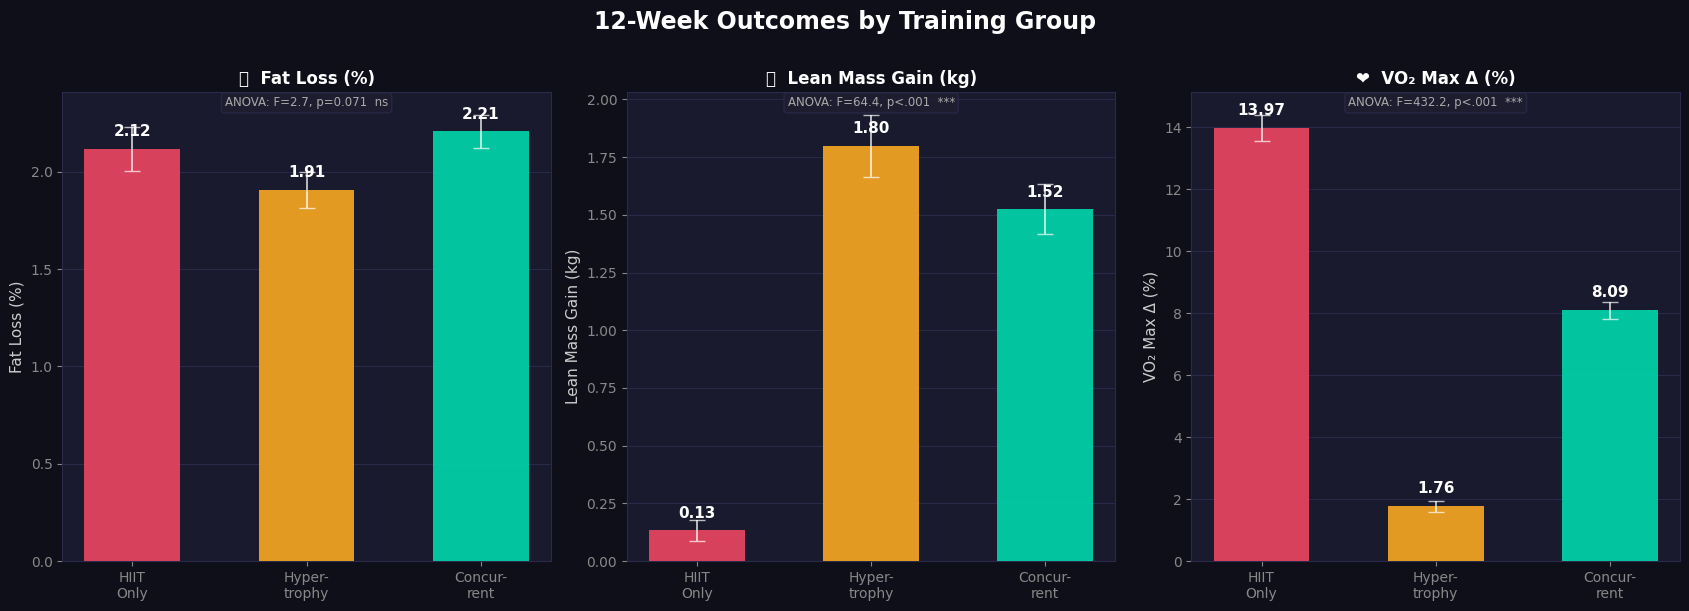

In [6]:
groups  = ['HIIT_Only', 'Hypertrophy_Only', 'Concurrent']
metrics = [
    ('Fat_Loss_Pct',      'Fat Loss (%)',         '🔥'),
    ('Lean_Mass_Gain_kg', 'Lean Mass Gain (kg)',  '💪'),
    ('VO2_Max_Change_Pct','VO₂ Max Δ (%)',        '❤️'),
]

fig, axes = plt.subplots(1, 3, figsize=(17, 6))
fig.patch.set_facecolor('#0f0f1a')
fig.suptitle('12-Week Outcomes by Training Group', fontsize=17,
             fontweight='bold', color='white', y=1.01)

for ax, (metric, label, emoji) in zip(axes, metrics):
    means  = [df[df.Group == g][metric].mean() for g in groups]
    sems   = [df[df.Group == g][metric].sem()  for g in groups]
    colors = [PALETTE[g] for g in groups]

    bars = ax.bar(range(3), means, yerr=sems, color=colors,
                  capsize=6, width=0.55, zorder=3,
                  error_kw=dict(ecolor='white', elinewidth=1.4, alpha=0.7),
                  edgecolor='none', alpha=0.92)
    ax.set_xticks(range(3))
    ax.set_xticklabels(['HIIT\nOnly', 'Hyper-\ntrophy', 'Concur-\nrent'], fontsize=10)
    ax.set_ylabel(label, fontsize=11)
    ax.set_title(f'{emoji}  {label}', fontsize=12, fontweight='bold')
    ax.grid(axis='y', zorder=0)
    ax.set_axisbelow(True)

    for bar, m in zip(bars, means):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(means)*0.03,
                f'{m:.2f}', ha='center', fontsize=11,
                fontweight='bold', color='white')

    # ANOVA annotation
    grp_data = [df[df.Group == g][metric].dropna() for g in groups]
    f, p = stats.f_oneway(*grp_data)
    sig = '***' if p < .001 else ('**' if p < .01 else ('*' if p < .05 else 'ns'))
    ax.annotate(f'ANOVA: F={f:.1f}, p{"<.001" if p<.001 else f"={p:.3f}"}  {sig}',
                xy=(0.5, 0.97), xycoords='axes fraction', ha='center',
                fontsize=8.5, color='#aaaaaa',
                bbox=dict(boxstyle='round,pad=0.3', facecolor='#1e1e30',
                          edgecolor='#2a2a4a', alpha=0.8))

plt.tight_layout()
plt.savefig('02_group_comparison.png', dpi=150, bbox_inches='tight',
            facecolor='#0f0f1a')
plt.show()


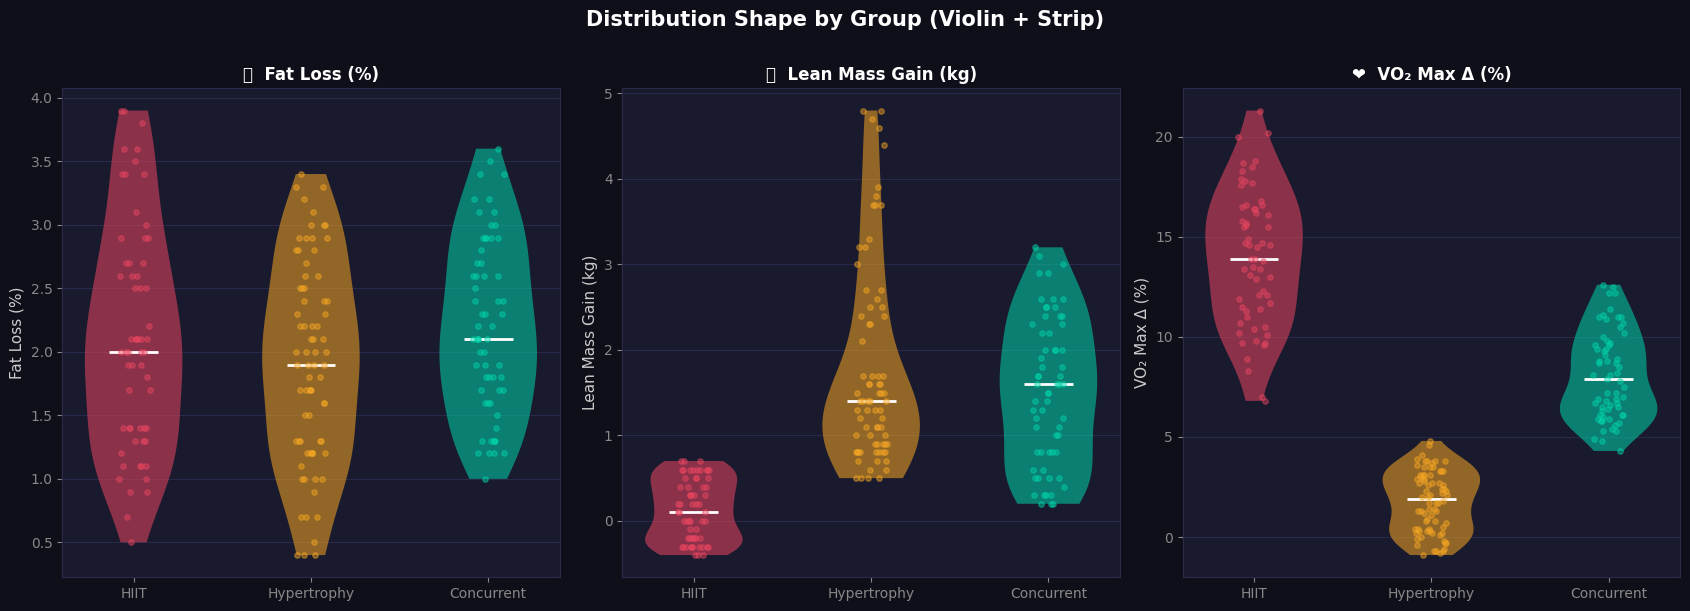

In [7]:
# Violin plots for distribution shape
fig, axes = plt.subplots(1, 3, figsize=(17, 6))
fig.patch.set_facecolor('#0f0f1a')
fig.suptitle('Distribution Shape by Group (Violin + Strip)', fontsize=15,
             fontweight='bold', color='white', y=1.01)

for ax, (metric, label, emoji) in zip(axes, metrics):
    for i, g in enumerate(groups):
        data = df[df.Group == g][metric].dropna()
        vp = ax.violinplot(data, positions=[i], widths=0.55,
                           showmedians=True, showextrema=False)
        for pc in vp['bodies']:
            pc.set_facecolor(PALETTE[g])
            pc.set_alpha(0.55)
        vp['cmedians'].set_color('white')
        vp['cmedians'].set_linewidth(2)
        # strip
        jitter = np.random.uniform(-0.09, 0.09, len(data))
        ax.scatter(i + jitter, data, color=PALETTE[g],
                   s=15, alpha=0.45, zorder=5)

    ax.set_xticks(range(3))
    ax.set_xticklabels(['HIIT', 'Hypertrophy', 'Concurrent'], fontsize=10)
    ax.set_ylabel(label, fontsize=11)
    ax.set_title(f'{emoji}  {label}', fontsize=12, fontweight='bold')
    ax.grid(axis='y', zorder=0)
    ax.set_axisbelow(True)

plt.tight_layout()
plt.savefig('03_violin_plots.png', dpi=150, bbox_inches='tight',
            facecolor='#0f0f1a')
plt.show()


## 5. Gender & Age Analysis <a id='5-demographics'></a>


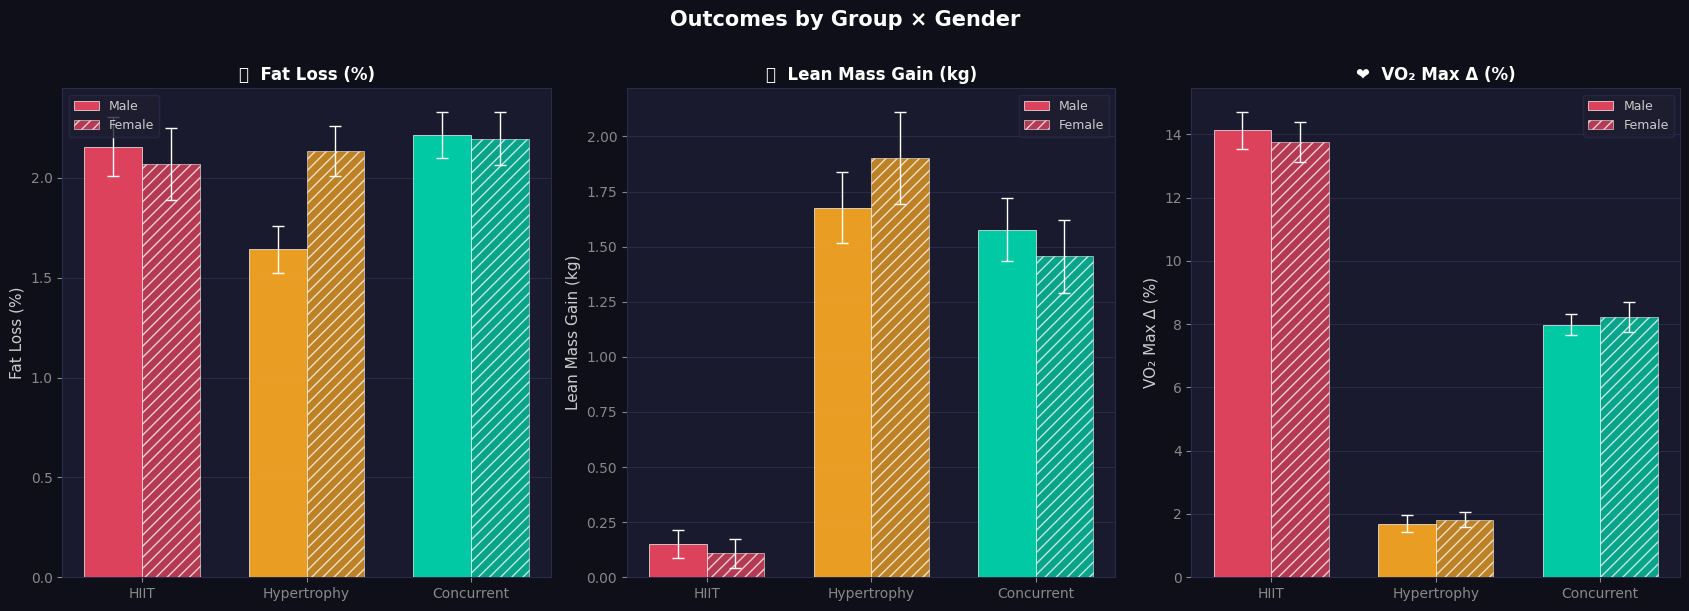

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(17, 6))
fig.patch.set_facecolor('#0f0f1a')
fig.suptitle('Outcomes by Group × Gender', fontsize=15,
             fontweight='bold', color='white', y=1.01)

bar_w = 0.35
for ax, (metric, label, emoji) in zip(axes, metrics):
    x = np.arange(3)
    for j, (gender, hatch, ealpha) in enumerate(
            [('Male', '', 0.95), ('Female', '///', 0.75)]):
        vals = [df[(df.Group==g) & (df.Gender==gender)][metric].mean()
                for g in groups]
        sems = [df[(df.Group==g) & (df.Gender==gender)][metric].sem()
                for g in groups]
        bars = ax.bar(x + j*bar_w - bar_w/2, vals, bar_w,
                      color=[PALETTE[g] for g in groups],
                      alpha=ealpha, hatch=hatch, edgecolor='white',
                      linewidth=0.5, yerr=sems, capsize=4,
                      error_kw=dict(ecolor='white', elinewidth=1),
                      label=gender, zorder=3)
    ax.set_xticks(x)
    ax.set_xticklabels(['HIIT', 'Hypertrophy', 'Concurrent'], fontsize=10)
    ax.set_ylabel(label, fontsize=11)
    ax.set_title(f'{emoji}  {label}', fontsize=12, fontweight='bold')
    ax.legend(fontsize=9)
    ax.grid(axis='y', zorder=0)
    ax.set_axisbelow(True)

plt.tight_layout()
plt.savefig('04_gender_analysis.png', dpi=150, bbox_inches='tight',
            facecolor='#0f0f1a')
plt.show()


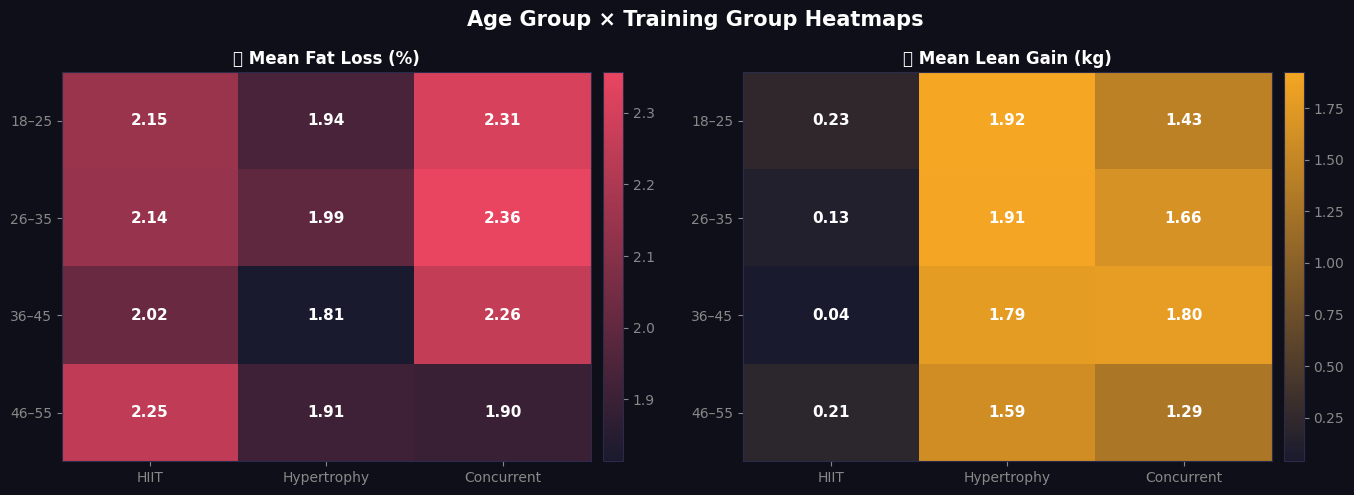

In [9]:
# Age group heatmap — mean fat loss
age_groups = ['18–25', '26–35', '36–45', '46–55']

pivot_fat  = pd.DataFrame(index=age_groups, columns=groups, dtype=float)
pivot_lean = pd.DataFrame(index=age_groups, columns=groups, dtype=float)
for ag in age_groups:
    for g in groups:
        sub = df[(df.Age_Group == ag) & (df.Group == g)]
        pivot_fat.loc[ag, g]  = sub['Fat_Loss_Pct'].mean()
        pivot_lean.loc[ag, g] = sub['Lean_Mass_Gain_kg'].mean()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
fig.patch.set_facecolor('#0f0f1a')
fig.suptitle('Age Group × Training Group Heatmaps', fontsize=15,
             fontweight='bold', color='white')

cmap_red  = LinearSegmentedColormap.from_list('red',  ['#1a1a2e','#e94560'])
cmap_gold = LinearSegmentedColormap.from_list('gold', ['#1a1a2e','#f5a623'])

for ax, pivot, cmap, title in [
    (ax1, pivot_fat,  cmap_red,  '🔥 Mean Fat Loss (%)'),
    (ax2, pivot_lean, cmap_gold, '💪 Mean Lean Gain (kg)'),
]:
    im = ax.imshow(pivot.values.astype(float), cmap=cmap, aspect='auto')
    ax.set_xticks(range(3))
    ax.set_xticklabels(['HIIT', 'Hypertrophy', 'Concurrent'], fontsize=10)
    ax.set_yticks(range(4))
    ax.set_yticklabels(age_groups, fontsize=10)
    ax.set_title(title, fontsize=12, fontweight='bold')
    for i in range(4):
        for j in range(3):
            v = pivot.values.astype(float)[i, j]
            ax.text(j, i, f'{v:.2f}', ha='center', va='center',
                    fontsize=11, fontweight='bold', color='white')
    plt.colorbar(im, ax=ax, pad=0.02)

plt.tight_layout()
plt.savefig('05_age_heatmap.png', dpi=150, bbox_inches='tight',
            facecolor='#0f0f1a')
plt.show()


## 6. Diet × Training Interaction <a id='6-diet'></a>


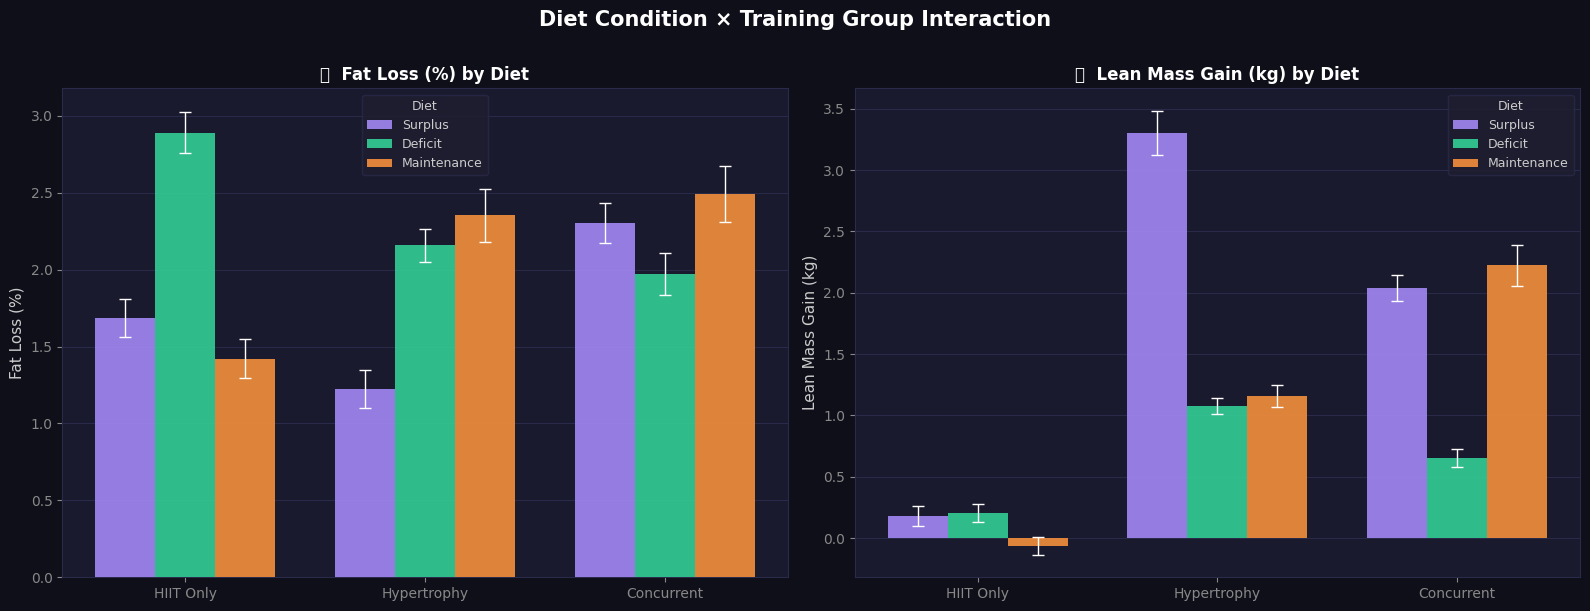

In [10]:
diets  = ['Surplus', 'Deficit', 'Maintenance']
d_col  = ['#a78bfa', '#34d399', '#fb923c']

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.patch.set_facecolor('#0f0f1a')
fig.suptitle('Diet Condition × Training Group Interaction', fontsize=15,
             fontweight='bold', color='white', y=1.01)

bar_w = 0.25
x = np.arange(3)
for ax, (metric, label, emoji) in zip(axes, metrics[:2]):
    for j, (diet, color) in enumerate(zip(diets, d_col)):
        vals = [df[(df.Group==g) & (df.Dietary_Condition==diet)][metric].mean()
                for g in groups]
        sems = [df[(df.Group==g) & (df.Dietary_Condition==diet)][metric].sem()
                for g in groups]
        ax.bar(x + (j-1)*bar_w, vals, bar_w,
               color=color, alpha=0.88, label=diet,
               yerr=sems, capsize=4,
               error_kw=dict(ecolor='white', elinewidth=1),
               edgecolor='none', zorder=3)
    ax.set_xticks(x)
    ax.set_xticklabels(['HIIT Only', 'Hypertrophy', 'Concurrent'], fontsize=10)
    ax.set_ylabel(label, fontsize=11)
    ax.set_title(f'{emoji}  {label} by Diet', fontsize=12, fontweight='bold')
    ax.legend(fontsize=9, title='Diet', title_fontsize=9)
    ax.grid(axis='y', zorder=0)
    ax.set_axisbelow(True)

plt.tight_layout()
plt.savefig('06_diet_interaction.png', dpi=150, bbox_inches='tight',
            facecolor='#0f0f1a')
plt.show()


## 7. Compliance Analysis <a id='7-compliance'></a>


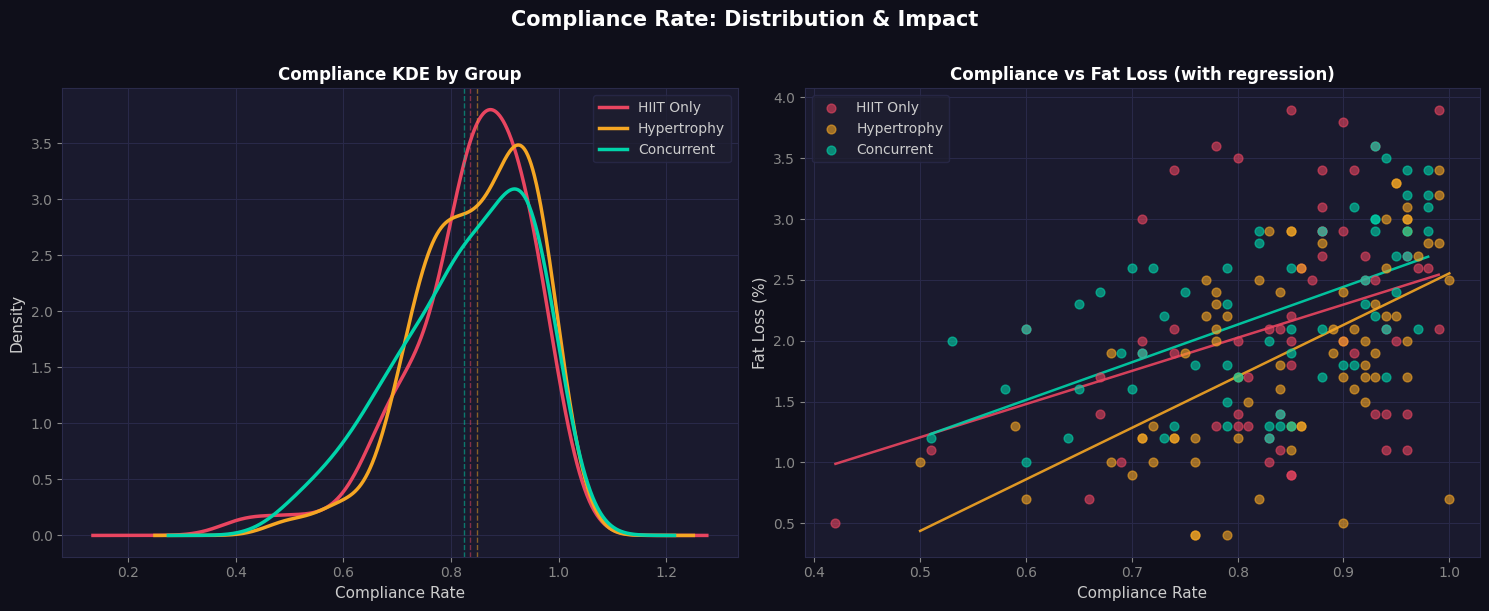

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.patch.set_facecolor('#0f0f1a')
fig.suptitle('Compliance Rate: Distribution & Impact', fontsize=15,
             fontweight='bold', color='white', y=1.01)

# KDE by group
ax = axes[0]
for g in groups:
    data = df[df.Group == g]['Compliance_Rate']
    data.plot.kde(ax=ax, color=PALETTE[g], linewidth=2.5, label=GROUP_LABELS[g])
    ax.axvline(data.mean(), color=PALETTE[g], linestyle='--', alpha=0.5, linewidth=1)
ax.set_xlabel('Compliance Rate', fontsize=11)
ax.set_ylabel('Density', fontsize=11)
ax.set_title('Compliance KDE by Group', fontsize=12, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, zorder=0)

# Scatter: compliance vs fat loss
ax = axes[1]
for g in groups:
    sub = df[df.Group == g]
    ax.scatter(sub['Compliance_Rate'], sub['Fat_Loss_Pct'],
               color=PALETTE[g], s=40, alpha=0.6, label=GROUP_LABELS[g], zorder=4)
    m, b, r, p, _ = stats.linregress(sub['Compliance_Rate'], sub['Fat_Loss_Pct'])
    xr = np.linspace(sub['Compliance_Rate'].min(), sub['Compliance_Rate'].max(), 80)
    ax.plot(xr, m*xr + b, color=PALETTE[g], linewidth=1.8, alpha=0.9)
ax.set_xlabel('Compliance Rate', fontsize=11)
ax.set_ylabel('Fat Loss (%)', fontsize=11)
ax.set_title('Compliance vs Fat Loss (with regression)', fontsize=12, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, zorder=0)
ax.set_axisbelow(True)

plt.tight_layout()
plt.savefig('07_compliance.png', dpi=150, bbox_inches='tight',
            facecolor='#0f0f1a')
plt.show()


## 8. Correlation Heatmap <a id='8-correlation'></a>


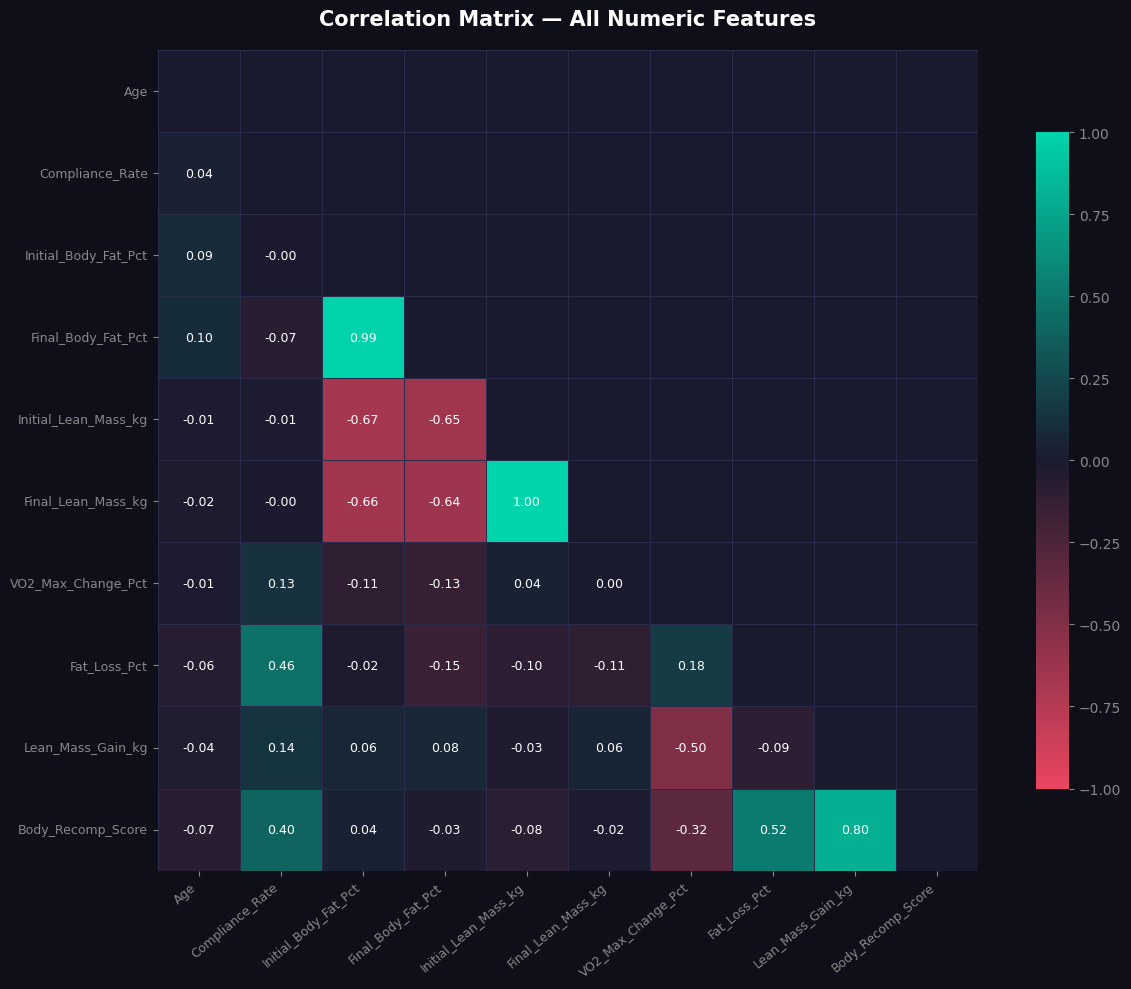

In [12]:
num_cols = ['Age','Compliance_Rate','Initial_Body_Fat_Pct','Final_Body_Fat_Pct',
            'Initial_Lean_Mass_kg','Final_Lean_Mass_kg','VO2_Max_Change_Pct',
            'Fat_Loss_Pct','Lean_Mass_Gain_kg','Body_Recomp_Score']

corr = df[num_cols].corr()

mask = np.triu(np.ones_like(corr, dtype=bool))
cmap = LinearSegmentedColormap.from_list(
    'diverge', ['#e94560','#1a1a2e','#00d4aa'])

fig, ax = plt.subplots(figsize=(13, 10))
fig.patch.set_facecolor('#0f0f1a')
sns.heatmap(corr, mask=mask, cmap=cmap, vmin=-1, vmax=1,
            annot=True, fmt='.2f', linewidths=0.5, linecolor='#2a2a4a',
            annot_kws={'size': 9, 'color': 'white'},
            cbar_kws={'shrink': 0.8}, ax=ax,
            square=True)
ax.set_title('Correlation Matrix — All Numeric Features', fontsize=15,
             fontweight='bold', pad=18)
ax.set_xticklabels(ax.get_xticklabels(), rotation=40, ha='right', fontsize=9)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=9)

plt.tight_layout()
plt.savefig('08_correlation.png', dpi=150, bbox_inches='tight',
            facecolor='#0f0f1a')
plt.show()


## 9. Scatter & Distribution Deep-Dives <a id='9-scatter'></a>


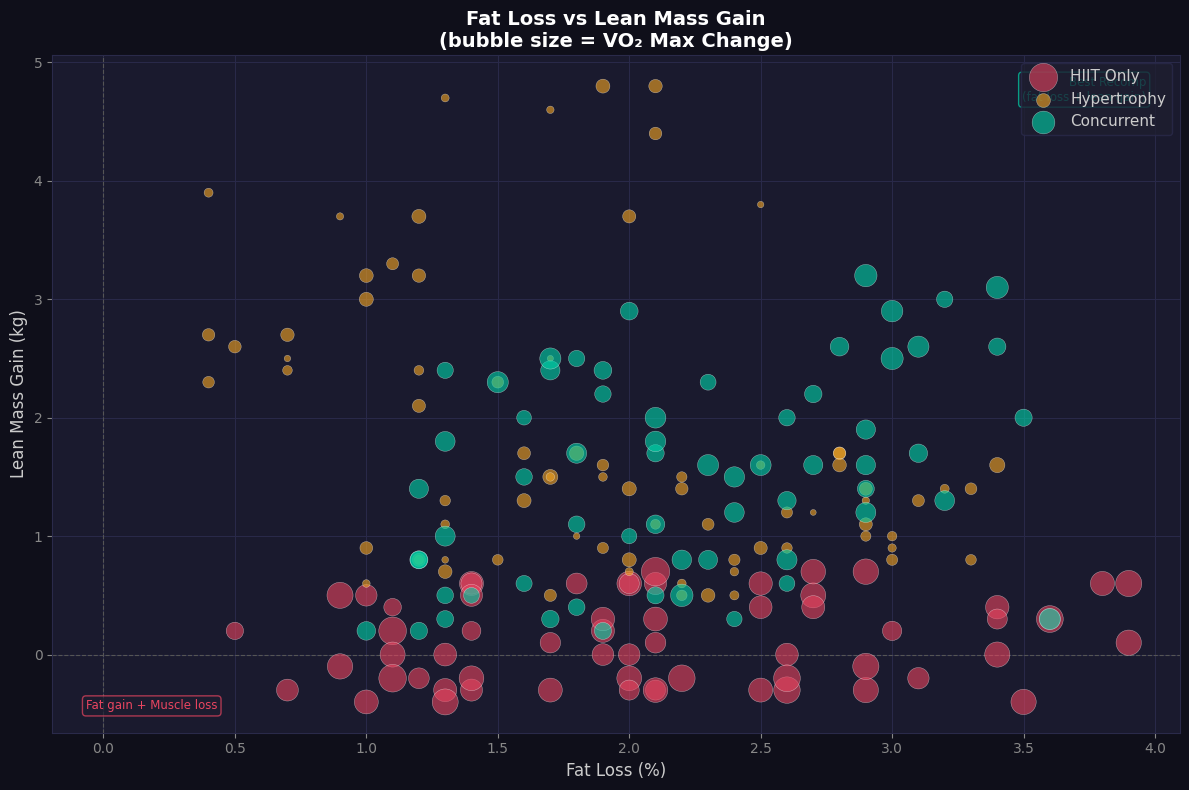

In [13]:
# Bubble chart: Fat Loss vs Lean Gain, size = VO2 change, color = group
fig, ax = plt.subplots(figsize=(12, 8))
fig.patch.set_facecolor('#0f0f1a')

for g in groups:
    sub = df[df.Group == g]
    sizes = (sub['VO2_Max_Change_Pct'] - df['VO2_Max_Change_Pct'].min() + 1) * 18
    sc = ax.scatter(sub['Fat_Loss_Pct'], sub['Lean_Mass_Gain_kg'],
                    s=sizes, c=PALETTE[g], alpha=0.6, label=GROUP_LABELS[g],
                    edgecolors='white', linewidths=0.3, zorder=4)

ax.axhline(0, color='#555', linewidth=0.8, linestyle='--')
ax.axvline(0, color='#555', linewidth=0.8, linestyle='--')
ax.set_xlabel('Fat Loss (%)', fontsize=12)
ax.set_ylabel('Lean Mass Gain (kg)', fontsize=12)
ax.set_title('Fat Loss vs Lean Mass Gain\n(bubble size = VO₂ Max Change)',
             fontsize=14, fontweight='bold')
ax.legend(fontsize=11, markerscale=1.2)
ax.grid(True, zorder=0)
ax.set_axisbelow(True)

# Quadrant labels
ax.text(0.97, 0.97, 'Best Recomp\n(fat loss + lean gain)',
        transform=ax.transAxes, ha='right', va='top',
        fontsize=8.5, color='#00d4aa',
        bbox=dict(boxstyle='round', facecolor='#1e1e30', edgecolor='#00d4aa', alpha=0.7))
ax.text(0.03, 0.03, 'Fat gain + Muscle loss',
        transform=ax.transAxes, ha='left', va='bottom',
        fontsize=8.5, color='#e94560',
        bbox=dict(boxstyle='round', facecolor='#1e1e30', edgecolor='#e94560', alpha=0.7))

plt.tight_layout()
plt.savefig('09_bubble_scatter.png', dpi=150, bbox_inches='tight',
            facecolor='#0f0f1a')
plt.show()


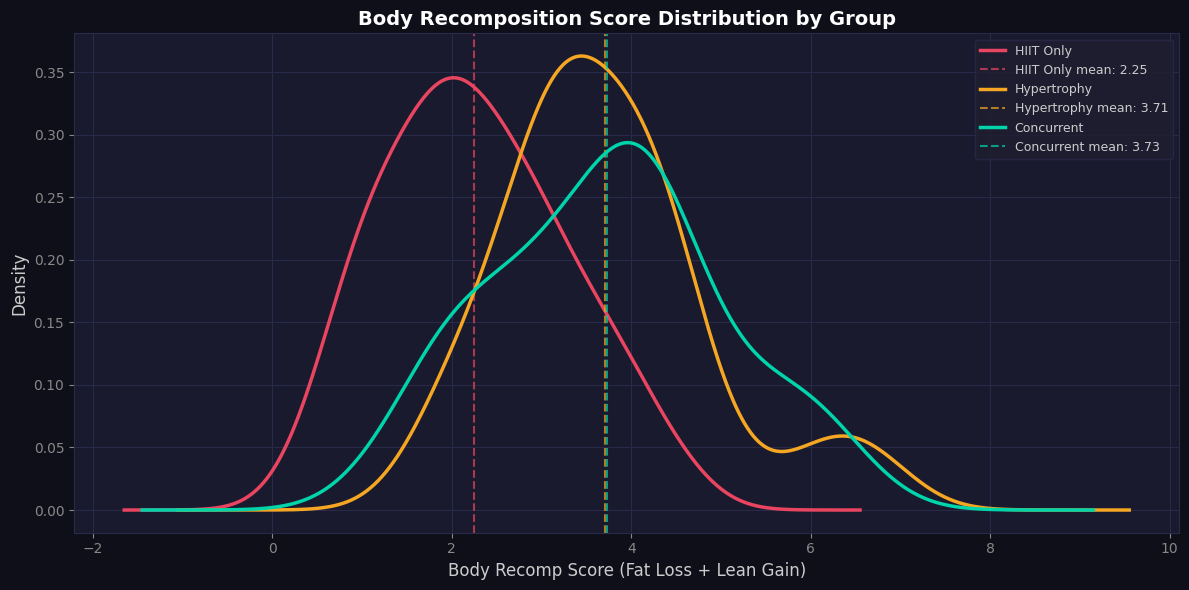

In [14]:
# Body Recomp Score distribution
fig, ax = plt.subplots(figsize=(12, 6))
fig.patch.set_facecolor('#0f0f1a')

for g in groups:
    data = df[df.Group == g]['Body_Recomp_Score']
    data.plot.kde(ax=ax, color=PALETTE[g], linewidth=2.5, label=GROUP_LABELS[g])
    ax.axvline(data.mean(), color=PALETTE[g], linestyle='--', alpha=0.7,
               linewidth=1.5, label=f'{GROUP_LABELS[g]} mean: {data.mean():.2f}')

ax.set_xlabel('Body Recomp Score (Fat Loss + Lean Gain)', fontsize=12)
ax.set_ylabel('Density', fontsize=12)
ax.set_title('Body Recomposition Score Distribution by Group', fontsize=14,
             fontweight='bold')
ax.legend(fontsize=9)
ax.grid(True, zorder=0)
ax.set_axisbelow(True)

plt.tight_layout()
plt.savefig('10_recomp_score.png', dpi=150, bbox_inches='tight',
            facecolor='#0f0f1a')
plt.show()


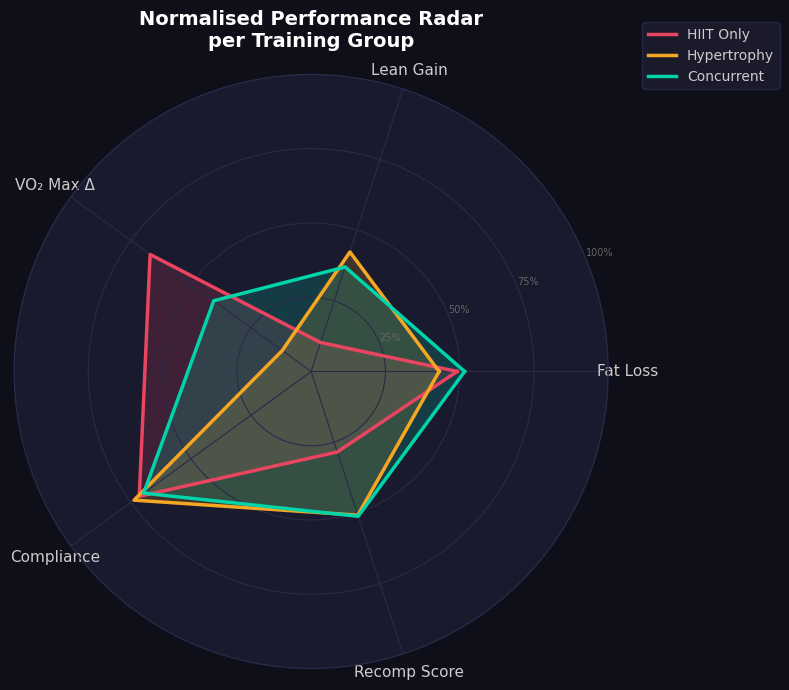

In [15]:
# Radar / Spider chart — normalised mean metrics per group
from matplotlib.patches import FancyArrowPatch

radar_metrics = ['Fat_Loss_Pct', 'Lean_Mass_Gain_kg', 'VO2_Max_Change_Pct',
                 'Compliance_Rate', 'Body_Recomp_Score']
radar_labels  = ['Fat Loss', 'Lean Gain', 'VO₂ Max Δ', 'Compliance', 'Recomp Score']
N = len(radar_metrics)

# Normalise to 0-1 per metric
norm_df = df.copy()
for m in radar_metrics:
    mn, mx = df[m].min(), df[m].max()
    norm_df[m] = (df[m] - mn) / (mx - mn + 1e-9)

angles = np.linspace(0, 2*np.pi, N, endpoint=False).tolist()
angles += angles[:1]

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))
fig.patch.set_facecolor('#0f0f1a')
ax.set_facecolor('#1a1a2e')

for g in groups:
    vals = [norm_df[norm_df.Group == g][m].mean() for m in radar_metrics]
    vals += vals[:1]
    ax.plot(angles, vals, color=PALETTE[g], linewidth=2.5, label=GROUP_LABELS[g])
    ax.fill(angles, vals, color=PALETTE[g], alpha=0.18)

ax.set_thetagrids(np.degrees(angles[:-1]), radar_labels, fontsize=11, color='#cccccc')
ax.set_ylim(0, 1)
ax.set_yticks([0.25, 0.5, 0.75, 1.0])
ax.set_yticklabels(['25%', '50%', '75%', '100%'], fontsize=7, color='#666')
ax.grid(color='#2a2a4a', linewidth=0.8)
ax.spines['polar'].set_color('#2a2a4a')
ax.set_title('Normalised Performance Radar\nper Training Group',
             fontsize=14, fontweight='bold', color='white', pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1), fontsize=10)

plt.tight_layout()
plt.savefig('11_radar.png', dpi=150, bbox_inches='tight',
            facecolor='#0f0f1a')
plt.show()


In [16]:
from itertools import combinations

print('=' * 65)
print('  POST-HOC PAIRWISE t-TESTS (Bonferroni-corrected, α=0.05)')
print('=' * 65)

pairs = list(combinations(groups, 2))
n_comparisons = len(pairs) * 3  # 3 metrics

for metric, label, _ in metrics:
    print(f'\n  Metric: {label}')
    print('  ' + '-' * 50)
    for g1, g2 in pairs:
        d1 = df[df.Group == g1][metric].dropna()
        d2 = df[df.Group == g2][metric].dropna()
        t, p = stats.ttest_ind(d1, d2)
        p_adj = min(p * n_comparisons, 1.0)   # Bonferroni
        sig = '***' if p_adj < .001 else ('**' if p_adj < .01 else
              ('*' if p_adj < .05 else 'ns'))
        cohen_d = (d1.mean() - d2.mean()) / np.sqrt(
            (d1.std()**2 + d2.std()**2) / 2)
        print(f'  {GROUP_LABELS[g1]:14s} vs {GROUP_LABELS[g2]:14s}'
              f'  p_adj={p_adj:.4f}  {sig:3s}  Cohen\'d={cohen_d:.2f}')


  POST-HOC PAIRWISE t-TESTS (Bonferroni-corrected, α=0.05)

  Metric: Fat Loss (%)
  --------------------------------------------------
  HIIT Only      vs Hypertrophy     p_adj=1.0000  ns   Cohen'd=0.25
  HIIT Only      vs Concurrent      p_adj=1.0000  ns   Cohen'd=-0.11
  Hypertrophy    vs Concurrent      p_adj=0.1761  ns   Cohen'd=-0.41

  Metric: Lean Mass Gain (kg)
  --------------------------------------------------
  HIIT Only      vs Hypertrophy     p_adj=0.0000  ***  Cohen'd=-1.91
  HIIT Only      vs Concurrent      p_adj=0.0000  ***  Cohen'd=-2.12
  Hypertrophy    vs Concurrent      p_adj=1.0000  ns   Cohen'd=0.27

  Metric: VO₂ Max Δ (%)
  --------------------------------------------------
  HIIT Only      vs Hypertrophy     p_adj=0.0000  ***  Cohen'd=4.66
  HIIT Only      vs Concurrent      p_adj=0.0000  ***  Cohen'd=2.07
  Hypertrophy    vs Concurrent      p_adj=0.0000  ***  Cohen'd=-3.35


In [17]:
summary = df.groupby('Group').agg(
    N=('Participant_ID', 'count'),
    Age_mean=('Age', 'mean'),
    Compliance_mean=('Compliance_Rate', 'mean'),
    Fat_Loss_mean=('Fat_Loss_Pct', 'mean'),
    Fat_Loss_std=('Fat_Loss_Pct', 'std'),
    Lean_Gain_mean=('Lean_Mass_Gain_kg', 'mean'),
    Lean_Gain_std=('Lean_Mass_Gain_kg', 'std'),
    VO2_mean=('VO2_Max_Change_Pct', 'mean'),
    Recomp_mean=('Body_Recomp_Score', 'mean'),
).round(2)

summary.index = [GROUP_LABELS[g] for g in summary.index]
print('=== 12-Week Summary Statistics ===')
summary


=== 12-Week Summary Statistics ===


,N,Age_mean,Compliance_mean,Fat_Loss_mean,Fat_Loss_std,Lean_Gain_mean,Lean_Gain_std,VO2_mean,Recomp_mean
Concurrent,63,35.33,0.82,2.21,0.69,1.52,0.86,8.09,3.73
HIIT Only,61,36.02,0.83,2.12,0.89,0.13,0.36,13.97,2.25
Hypertrophy,76,36.24,0.85,1.91,0.79,1.80,1.18,1.76,3.71


## 10. Key Takeaways <a id='10-takeaways'></a>

<div style="background:linear-gradient(135deg,#0f0f1a,#1a1a2e);border-radius:14px;padding:30px 36px;font-family:'Segoe UI',sans-serif;border:1px solid #2a2a4a;">

<h2 style="color:#ffffff;margin-top:0;font-size:1.4rem;">📊 Study Conclusions</h2>

<div style="display:grid;grid-template-columns:1fr 1fr;gap:18px;margin-bottom:20px;">

  <div style="background:#1e1e30;border-radius:10px;padding:18px;border-left:4px solid #e94560;">
    <h3 style="color:#e94560;margin:0 0 8px;font-size:1rem;">🏃 HIIT Only</h3>
    <ul style="color:#ccc;margin:0;padding-left:18px;line-height:1.8;font-size:0.88rem;">
      <li>Best VO₂ Max improvement: <strong style='color:#e94560'>+13.97%</strong></li>
      <li>Strong fat loss: <strong style='color:#e94560'>2.12%</strong> average</li>
      <li>Minimal lean mass change: <strong>+0.13 kg</strong></li>
      <li>Ideal for: cardiovascular fitness & fat loss without hypertrophy goal</li>
    </ul>
  </div>

  <div style="background:#1e1e30;border-radius:10px;padding:18px;border-left:4px solid #f5a623;">
    <h3 style="color:#f5a623;margin:0 0 8px;font-size:1rem;">🏋️ Hypertrophy Only</h3>
    <ul style="color:#ccc;margin:0;padding-left:18px;line-height:1.8;font-size:0.88rem;">
      <li>Highest lean mass gain: <strong style='color:#f5a623'>+1.80 kg</strong></li>
      <li>Moderate fat loss: <strong>1.91%</strong></li>
      <li>Negligible VO₂ change: <strong>+1.76%</strong></li>
      <li>Ideal for: muscle building and body recomposition</li>
    </ul>
  </div>

  <div style="background:#1e1e30;border-radius:10px;padding:18px;border-left:4px solid #00d4aa;">
    <h3 style="color:#00d4aa;margin:0 0 8px;font-size:1rem;">⚡ Concurrent Training</h3>
    <ul style="color:#ccc;margin:0;padding-left:18px;line-height:1.8;font-size:0.88rem;">
      <li>Best overall fat loss: <strong style='color:#00d4aa'>2.21%</strong></li>
      <li>Solid lean gain: <strong style='color:#00d4aa'>+1.52 kg</strong></li>
      <li>Balanced VO₂ improvement: <strong>+8.09%</strong></li>
      <li>Ideal for: complete body recomposition — the all-rounder protocol</li>
    </ul>
  </div>

  <div style="background:#1e1e30;border-radius:10px;padding:18px;border-left:4px solid #a78bfa;">
    <h3 style="color:#a78bfa;margin:0 0 8px;font-size:1rem;">🍽️ Diet Matters Too</h3>
    <ul style="color:#ccc;margin:0;padding-left:18px;line-height:1.8;font-size:0.88rem;">
      <li>Caloric deficit amplified fat loss across all groups</li>
      <li>Caloric surplus drove lean mass gains (especially Hypertrophy)</li>
      <li>Maintenance diet showed moderate recomp in Concurrent group</li>
      <li>Diet × training interaction is significant and non-trivial</li>
    </ul>
  </div>

</div>

<div style="background:#1e1e30;border-radius:10px;padding:16px 20px;border:1px solid #2a2a4a;">
  <p style="color:#aaa;margin:0;font-size:0.88rem;line-height:1.7;">
    <strong style='color:#fff;'>⚠️ Limitations:</strong> All participants completed 12 weeks with fixed protocol duration.
    Individual genetic factors, sleep, and stress are not controlled. The Body Recomp Score
    is a composite heuristic and not a validated clinical metric. Results should not be
    generalised beyond the studied population without further replication.
  </p>
</div>

<div style="margin-top:16px;text-align:right;color:#444;font-size:0.78rem;">Author: Muhammad Aamir &nbsp;·&nbsp; Notebook Version 1.0</div>

</div>
